# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%load_ext autoreload
%autoreload 2
from src.utils import print_images, stratified_split, set_seed, get_stratified_sample
from src.PCA import standardize_data, pca_fit, pca_transform, pca_inverse_transform
from src.AE import AE, Trainer, get_dataloaders
from src.clustering import k_means, GMM, silhouette_score, tsne

RANDOM_SEED = 1973

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## EDA

In [2]:
df = pd.read_csv("data/raw/fashion_mnist_subset.csv")
y = df["label"]
X = df.drop(columns=["label"])

# Verificar shape
print("X shape:", X.shape)  
print("y shape:", y.shape)
print("Labels:", np.unique(y))

np.save("data/raw/X_images.npy", X)
np.save("data/raw/y_labels.npy", y)

X shape: (25000, 784)
y shape: (25000,)
Labels: [0 1 2 3 4 5 6 7 8 9]


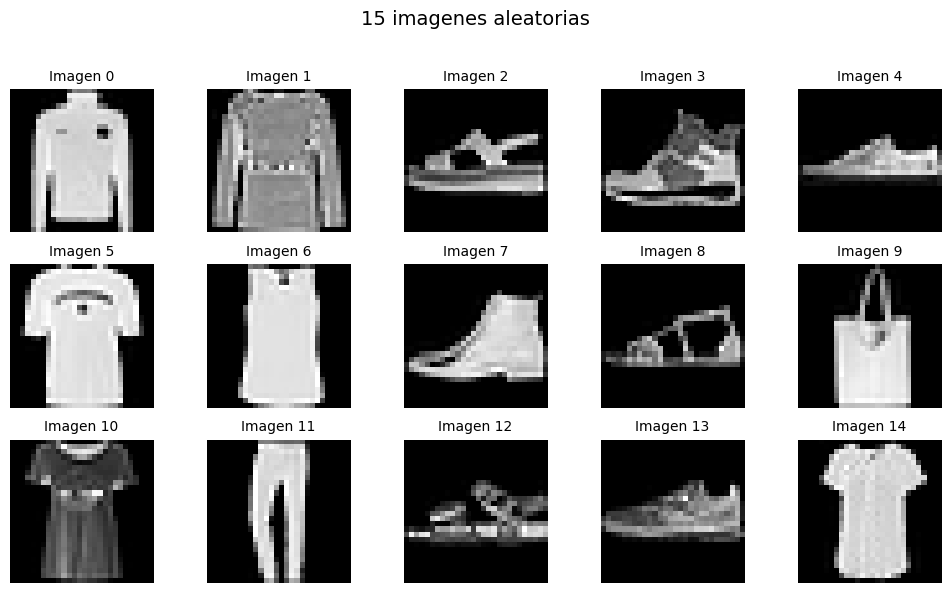

In [3]:
X = np.load("data/raw/X_images.npy")
y = np.load("data/raw/y_labels.npy")
N = 15

print_images(N, X, f"{N} imagenes aleatorias",RANDOM_SEED)

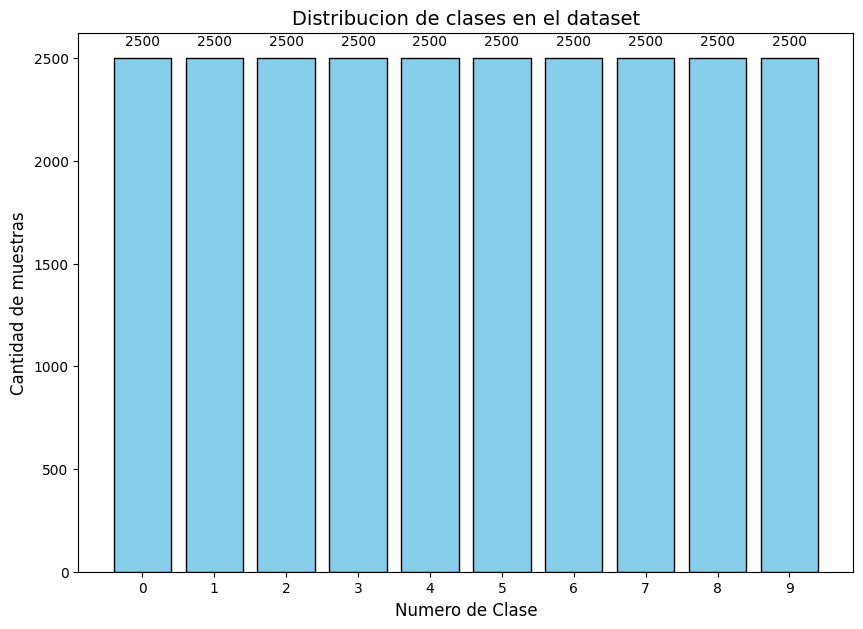

In [4]:
# Grafico de distribucion de clases

clases, conteos = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 7))

bars = plt.bar(clases, conteos, color='skyblue', edgecolor='black')

plt.title('Distribucion de clases en el dataset', fontsize=14)
plt.xlabel('Numero de Clase', fontsize=12)
plt.ylabel('Cantidad de muestras', fontsize=12)

plt.xticks(clases)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), 
             ha='center', va='bottom', fontsize=10)

plt.show()

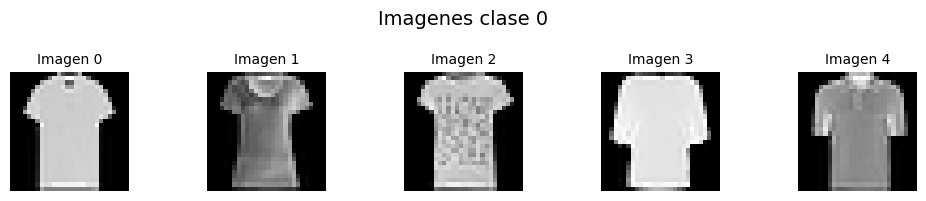

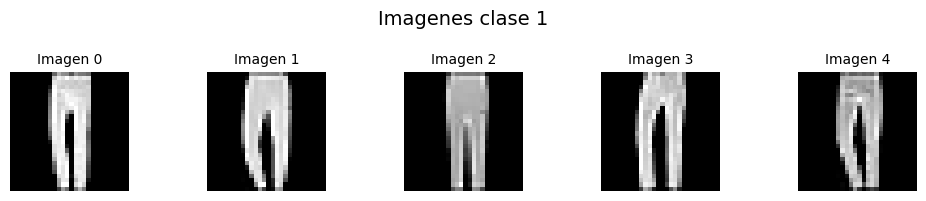

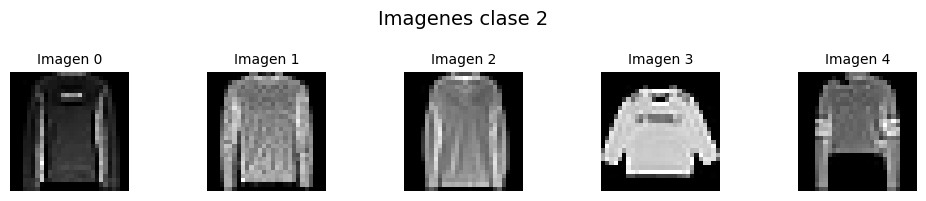

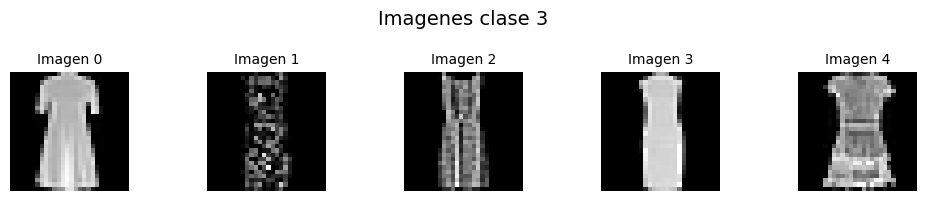

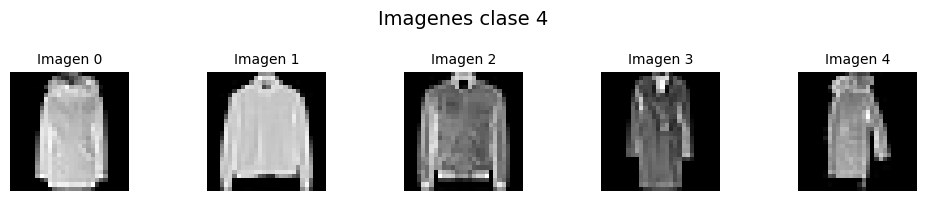

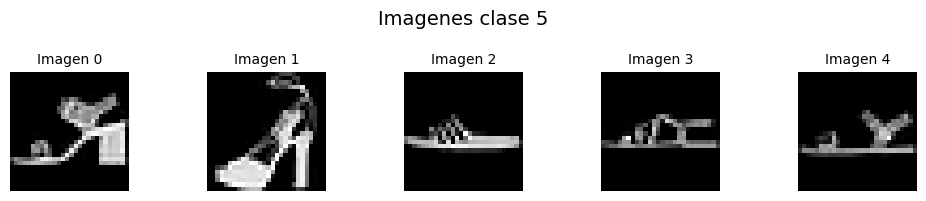

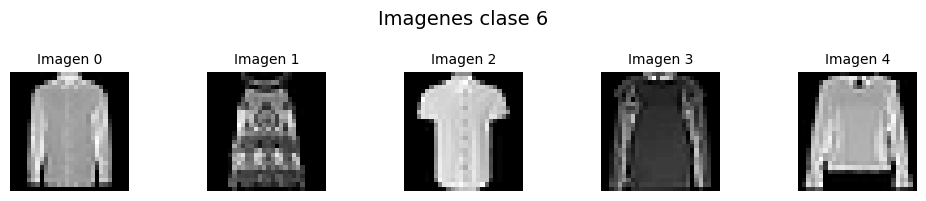

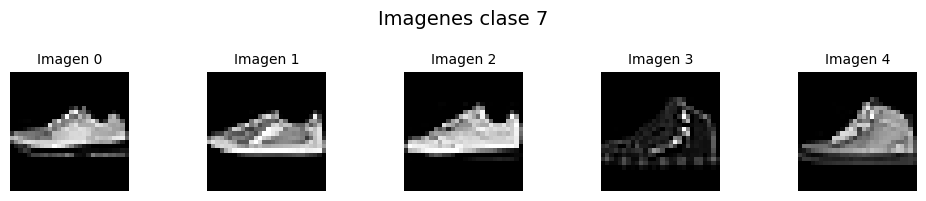

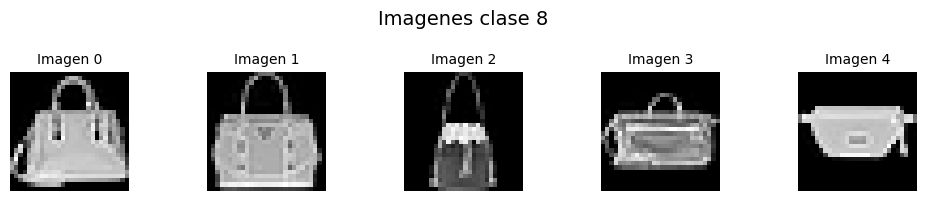

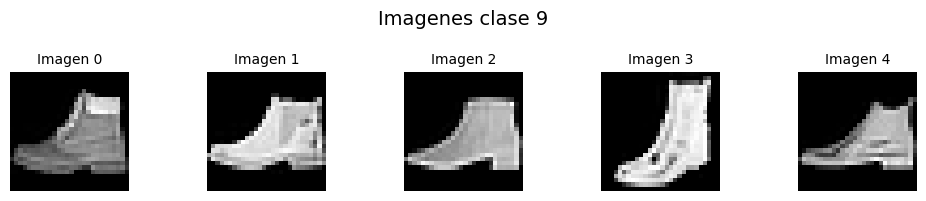

In [5]:
for i in np.unique(y):
    class_images = X[y == i]
    print_images(
        5,
        class_images,
        random_seed=RANDOM_SEED+i,
        title=f"Imagenes clase {i}"
    )

In [6]:
# Hago un split 80/20 manteniendo la misma proporcion de cada clase en train y validation

X_train, X_val, y_train, y_val = stratified_split(X, y, 0.8)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")

for label in np.unique(y):
    train_count = np.sum(y_train == label)
    val_count = np.sum(y_val == label)

    print(
        f"Clase {label}: "
        f"train={train_count}/{len(y_train)} ({train_count / len(y_train):.1%}), "
        f"val={val_count}/{len(y_val)} ({val_count / len(y_val):.1%})"
    )

np.save("data/preprocessed/X_train.npy", X_train)
np.save("data/preprocessed/X_val.npy", X_val)
np.save("data/preprocessed/y_train.npy", y_train)
np.save("data/preprocessed/y_val.npy", y_val)

Train size: 20000
Val size: 5000
Clase 0: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 1: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 2: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 3: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 4: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 5: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 6: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 7: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 8: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 9: train=2000/20000 (10.0%), val=500/5000 (10.0%)


## Reducción de dimensionalidad

### PCA

In [7]:
# Estandarizo losa datos de train
X_train_std, mean_train, std_train = standardize_data(X_train)

# fiteo y aplico PCA a los datos de train
components_train, variance_ratio = pca_fit(X_train_std)
n_comp = 100 # Tomo un numero de componentes arbitrario para checkear que funcione
X_train_pca = pca_transform(X_train_std, components_train, n_comp)

# Estandarizo los datos de validation usando la media y std del train
X_val_std, _, _ = standardize_data(X_val, mean=mean_train, std=std_train)
X_val_pca = pca_transform(X_val_std, components_train, n_comp)

print("Verificacion de Dimensiones")

# Chequeo de los datos originales
print(f"Dimensiones de X_train original: {X_train.shape}")
print(f"Dimensiones de X_val original: {X_val.shape}")

# Chequeo de los datos estandarizados
print(f"Dimensiones de X_train_std: {X_train_std.shape}")
print(f"Dimensiones de X_val_std: {X_val_std.shape}")

# Chequeo de los componentes obtenidos por SVD
print(f"Dimensiones de matriz Vt: {components_train.shape}")

# Chequeo de los datos reducidos
print(f"Dimensiones de X_train_pca: {X_train_pca.shape}")
print(f"Dimensiones de X_val_pca: {X_val_pca.shape}")

Verificacion de Dimensiones
Dimensiones de X_train original: (20000, 784)
Dimensiones de X_val original: (5000, 784)
Dimensiones de X_train_std: (20000, 784)
Dimensiones de X_val_std: (5000, 784)
Dimensiones de matriz Vt: (784, 784)
Dimensiones de X_train_pca: (20000, 100)
Dimensiones de X_val_pca: (5000, 100)


Numero de componentes necesarios para explicar el 90% de la varianza: 134


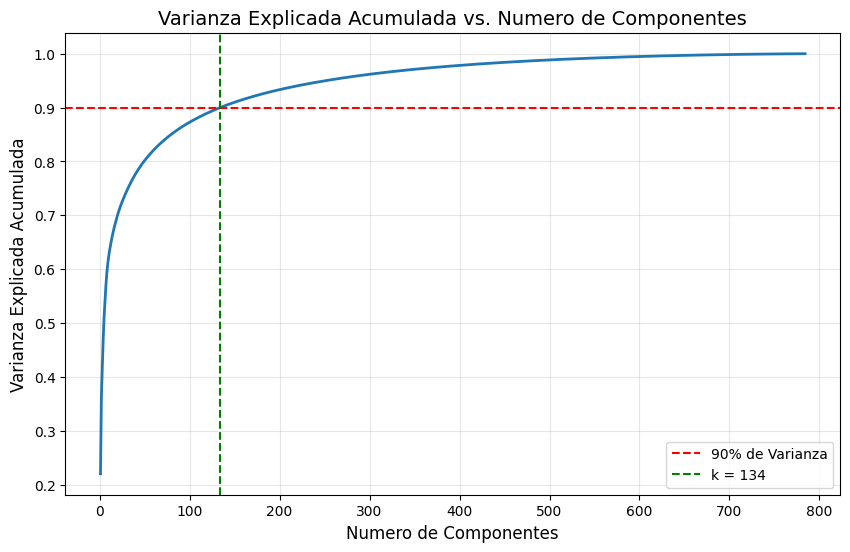

In [8]:
# varianza acumulada de los componentes
cumulative_variance = np.cumsum(variance_ratio)

# busco el k para tener el 90% de varianza explicada
k_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Numero de componentes necesarios para explicar el 90% de la varianza: {k_90}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de Varianza')
plt.axvline(x=k_90, color='g', linestyle='--', label=f'k = {k_90}')
plt.title('Varianza Explicada Acumulada vs. Numero de Componentes', fontsize=14)
plt.xlabel('Numero de Componentes', fontsize=12)
plt.ylabel('Varianza Explicada Acumulada', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

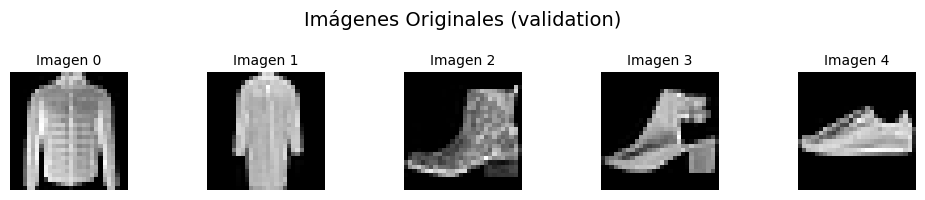

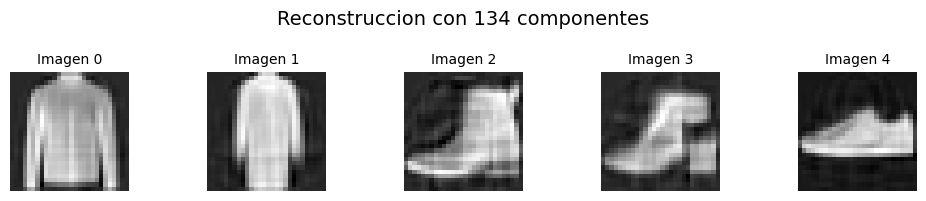

In [9]:
# transformo los datos de validation usando los k_90 componentes necesarios para explicar el 90% de la varianza
X_val_pca_90 = pca_transform(X_val_std, components_train, k_90)

# reconstruyo las imagenes a partir de esos k_90 componentes
X_val_reconstructed = pca_inverse_transform(X_val_pca_90, components_train, k_90, mean_train, std_train)

print_images(5, X_val, random_seed=RANDOM_SEED, title="Imágenes Originales (validation)")
print_images(5, X_val_reconstructed, random_seed=RANDOM_SEED, title=f"Reconstruccion con {k_90} componentes")

### Autoencoder deterministico (AE)

Early Stopping en epoch 98!
--------------------------------------------------
Entrenamiento finalizado.
El modelo restauró sus pesos a la epoch 83.
Validation Loss final retenida: 0.1374
--------------------------------------------------


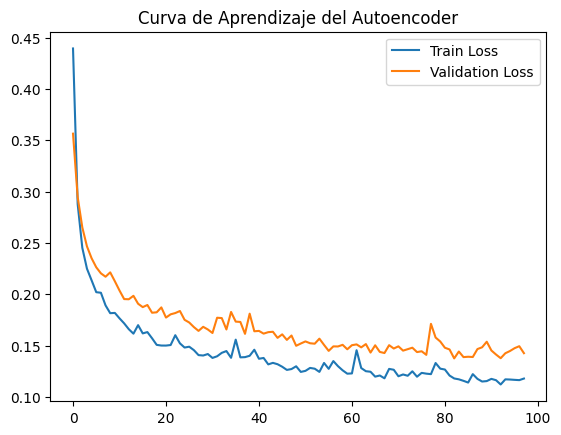

In [10]:
set_seed(RANDOM_SEED)

train_loader, val_loader = get_dataloaders(X_train_std, y_train, X_val_std, y_val)
input_dimension = X_train_std.shape[1] 
latent_dimension = k_90 # Uso el mismo numero de componentes que para PCA para comparar resultados

autoencoder = AE(input_dim=input_dimension, latent_dim=latent_dimension, dropout_p=0.01)

trainer = Trainer(autoencoder, train_loader, val_loader, lr=0.001)
loss_history, val_loss_history = trainer.train(early_stopping=True, patience=15, epochs=200)

mejor_val_loss = min(val_loss_history)
mejor_epoch = val_loss_history.index(mejor_val_loss) + 1

print("-" * 50)
print(f"Entrenamiento finalizado.")
print(f"El modelo restauró sus pesos a la epoch {mejor_epoch}.")
print(f"Validation Loss final retenida: {mejor_val_loss:.4f}")
print("-" * 50)

# Grafico de la learning curve del autoencoder
plt.plot(loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.legend()
plt.title('Curva de Aprendizaje del Autoencoder')
plt.show()

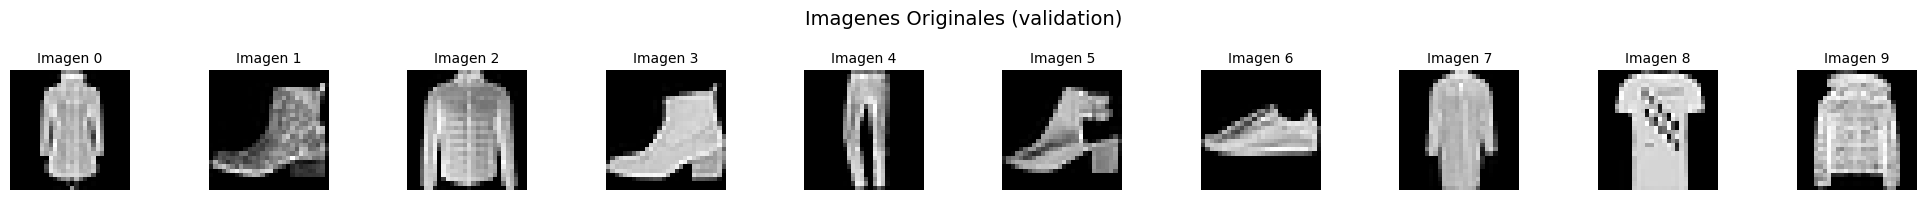

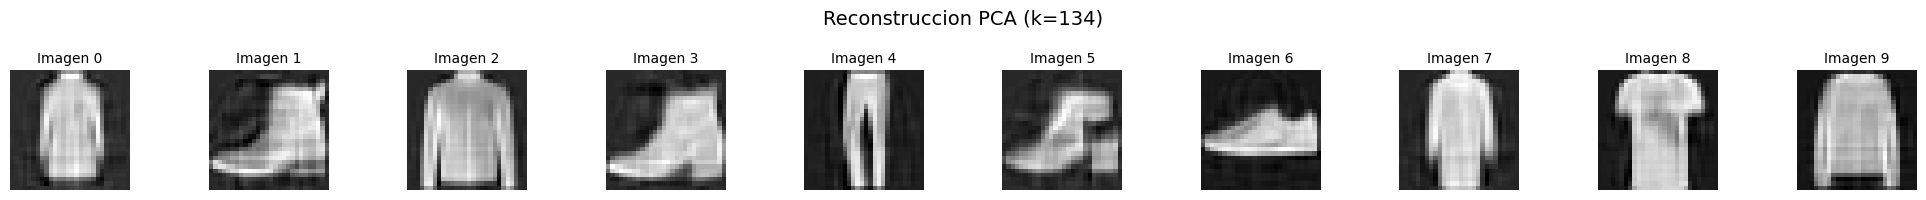

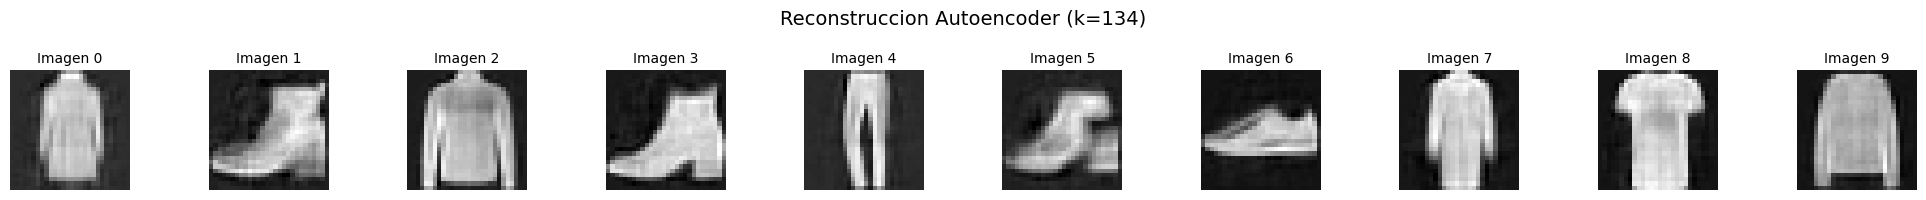

In [11]:
np.random.seed(RANDOM_SEED) 
indices = np.random.choice(len(X_val), 10, replace=False)

# muestras aleaotrias de validation para comparar las reconstrucciones
X_sample_std = X_val_std[indices]
X_sample_original = X_val[indices]

# reconstruccion con PCA
X_sample_pca_latente = pca_transform(X_sample_std, components_train, k_90)
X_sample_pca_rec = pca_inverse_transform(X_sample_pca_latente, components_train, k_90, mean_train, std_train)

# reconstruccion con Autoencoder
X_sample_ae_std_rec = autoencoder.reconstruct(X_sample_std)
X_sample_ae_rec = (X_sample_ae_std_rec * std_train) + mean_train

print_images(10, X_sample_original, random_seed=RANDOM_SEED, title="Imagenes Originales (validation)", cols=10)
print_images(10, X_sample_pca_rec, random_seed=RANDOM_SEED, title=f"Reconstruccion PCA (k={k_90})", cols=10)
print_images(10, X_sample_ae_rec, random_seed=RANDOM_SEED, title=f"Reconstruccion Autoencoder (k={latent_dimension})", cols=10)


In [12]:
# Dimension latente PCA
X_train_pca = pca_transform(X_train_std, components_train, k_90)
X_val_pca = pca_transform(X_val_std, components_train, k_90)
print(f"Forma de X_train_pca: {X_train_pca.shape}")
print(f"Forma de X_val_pca: {X_val_pca.shape}\n")

# Dimension latente Autoencoder
X_train_ae = autoencoder.get_latent_features(X_train_std)
X_val_ae = autoencoder.get_latent_features(X_val_std)
print(f"Forma de X_train_ae: {X_train_ae.shape}")
print(f"Forma de X_val_ae: {X_val_ae.shape}")



Forma de X_train_pca: (20000, 134)
Forma de X_val_pca: (5000, 134)

Forma de X_train_ae: (20000, 134)
Forma de X_val_ae: (5000, 134)


## Clustering

In [13]:
# 3000 puntos para PCA
X_pca_3k, y_pca_3k = get_stratified_sample(X_train_pca, y_train, n_samples=3000)

# 3000 puntos para Autoencoder
X_ae_3k, y_ae_3k = get_stratified_sample(X_train_ae, y_train, n_samples=3000)

print(f"X_pca_3k: {X_pca_3k.shape} | y_pca_3k: {y_pca_3k.shape}")
print(f"X_ae_3k:  {X_ae_3k.shape} | y_ae_3k:  {y_ae_3k.shape}")

# verifico que la distribucion de clases se mantuvo en el subset de PCA
_, conteos = np.unique(y_pca_3k, return_counts=True)
print(f"Muestras por clase en el subset: {conteos}")

X_pca_3k: (3000, 134) | y_pca_3k: (3000,)
X_ae_3k:  (3000, 134) | y_ae_3k:  (3000,)
Muestras por clase en el subset: [300 300 300 300 300 300 300 300 300 300]


In [14]:
k_values = range(5, 16)
losses_pca_kmeans = []
losses_ae_kmeans = []
labels_pca_dict_kmeans = {} 
labels_ae_dict_kmeans = {}

for k in k_values:
    # K-Means sobre el espacio latente de PCA
    _, labels_pca, loss_pca = k_means(X_pca_3k, n_clusters=k, random_seed=RANDOM_SEED)
    losses_pca_kmeans.append(loss_pca)
    labels_pca_dict_kmeans[k] = labels_pca
    
    # K-Means sobre el espacio latente del Autoencoder
    _, labels_ae, loss_ae = k_means(X_ae_3k, n_clusters=k, random_seed=RANDOM_SEED)
    losses_ae_kmeans.append(loss_ae)
    labels_ae_dict_kmeans[k] = labels_ae
    
    print(f"K = {k:2d} | Loss PCA: {loss_pca:.2f} | Loss AE: {loss_ae:.2f}")

K =  5 | Loss PCA: 1304522.19 | Loss AE: 731146.44
K =  6 | Loss PCA: 1238978.45 | Loss AE: 710592.38
K =  7 | Loss PCA: 1174321.83 | Loss AE: 691722.69
K =  8 | Loss PCA: 1135801.60 | Loss AE: 678904.12
K =  9 | Loss PCA: 1098325.21 | Loss AE: 658463.81
K = 10 | Loss PCA: 1061745.41 | Loss AE: 647372.75
K = 11 | Loss PCA: 1028675.47 | Loss AE: 635475.38
K = 12 | Loss PCA: 999093.99 | Loss AE: 626154.62
K = 13 | Loss PCA: 972560.04 | Loss AE: 621386.00
K = 14 | Loss PCA: 952688.39 | Loss AE: 611723.12
K = 15 | Loss PCA: 942090.28 | Loss AE: 605672.50


In [15]:
k_values = range(5, 16)

log_likelihood_pca = []
log_likelihood_ae = []
labels_pca_dict_gmm = {}
labels_ae_dict_gmm = {}

for k in k_values:
    # GMM sobre el espacio latente de PCA
    _, _, _, labels_pca, ll_p = GMM(X_pca_3k, n_clusters=k, random_seed=RANDOM_SEED)
    log_likelihood_pca.append(ll_p)
    labels_pca_dict_gmm[k] = labels_pca
    
    # GMM sobre el espacio latente del Autoencoder
    _, _, _, labels_ae, ll_a = GMM(X_ae_3k, n_clusters=k, random_seed=RANDOM_SEED)
    log_likelihood_ae.append(ll_a)
    labels_ae_dict_gmm[k] = labels_ae
    
    print(f"K = {k:2d} | Log-Likelihood PCA: {ll_p:.2f} | Log-Likelihood AE: {ll_a:.2f}")

K =  5 | Log-Likelihood PCA: -205218.54 | Log-Likelihood AE: -345905.28
K =  6 | Log-Likelihood PCA: -183596.08 | Log-Likelihood AE: -323175.14
K =  7 | Log-Likelihood PCA: -186404.00 | Log-Likelihood AE: -287537.05
K =  8 | Log-Likelihood PCA: -139743.18 | Log-Likelihood AE: -250821.51
K =  9 | Log-Likelihood PCA: -153473.39 | Log-Likelihood AE: -244287.02
K = 10 | Log-Likelihood PCA: -133679.65 | Log-Likelihood AE: -230855.49
K = 11 | Log-Likelihood PCA: -101663.27 | Log-Likelihood AE: -211427.46
K = 12 | Log-Likelihood PCA: -95703.07 | Log-Likelihood AE: -183835.25
K = 13 | Log-Likelihood PCA: -83248.44 | Log-Likelihood AE: -158698.83
K = 14 | Log-Likelihood PCA: -67554.34 | Log-Likelihood AE: -151051.98
K = 15 | Log-Likelihood PCA: -50842.23 | Log-Likelihood AE: -120395.01


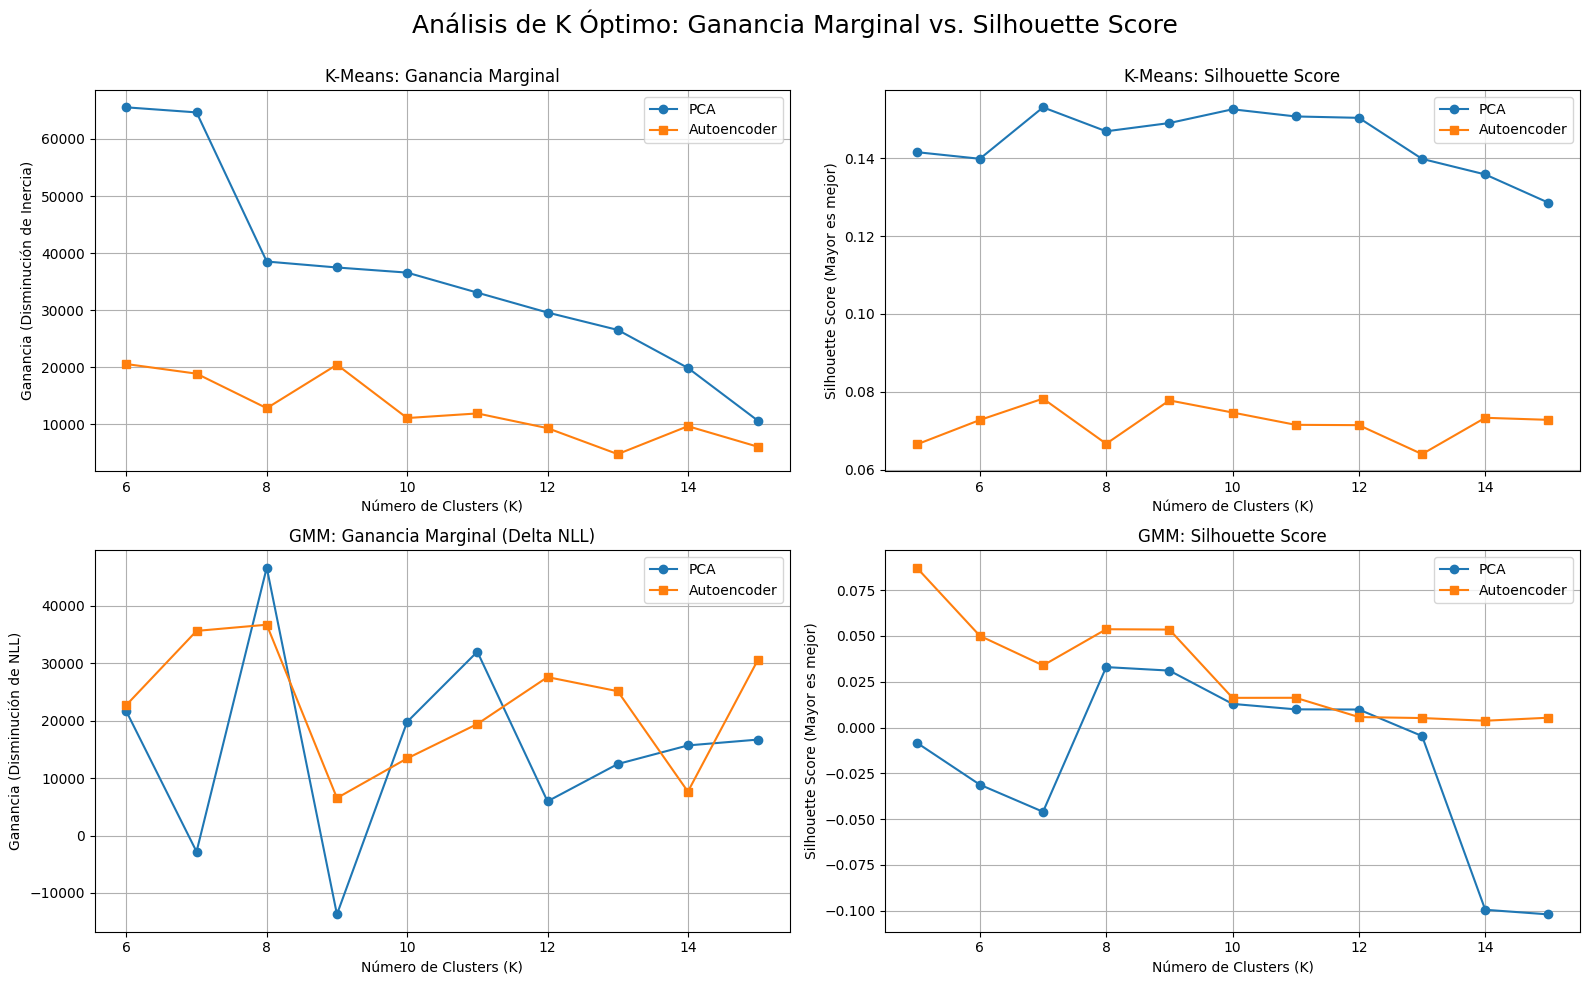

In [20]:
# --- 1. Cálculos para K-Means ---
# Ganancia marginal: Loss(K-1) - Loss(K)
# Como empezamos en K=5, el primer salto calculable es en K=6
marginal_gain_pca_kmeans = [losses_pca_kmeans[i] - losses_pca_kmeans[i+1] for i in range(len(losses_pca_kmeans)-1)]
marginal_gain_ae_kmeans = [losses_ae_kmeans[i] - losses_ae_kmeans[i+1] for i in range(len(losses_ae_kmeans)-1)]

# Silhouette Score
silhouette_pca_kmeans = [silhouette_score(X_pca_3k, labels_pca_dict_kmeans[k]) for k in k_values]
silhouette_ae_kmeans = [silhouette_score(X_ae_3k, labels_ae_dict_kmeans[k]) for k in k_values]


# --- 2. Cálculos para GMM ---
# NLL (Negative Log-Likelihood) para poder ver la ganancia de forma descendente
nll_pca = [-ll for ll in log_likelihood_pca]
nll_ae = [-ll for ll in log_likelihood_ae]

marginal_gain_pca_gmm = [nll_pca[i] - nll_pca[i+1] for i in range(len(nll_pca)-1)]
marginal_gain_ae_gmm = [nll_ae[i] - nll_ae[i+1] for i in range(len(nll_ae)-1)]

# Silhouette Score
silhouette_pca_gmm = [silhouette_score(X_pca_3k, labels_pca_dict_gmm[k]) for k in k_values]
silhouette_ae_gmm = [silhouette_score(X_ae_3k, labels_ae_dict_gmm[k]) for k in k_values]

# --- 3. Graficación (Subplots de 2x2) ---
k_values_marginal = list(k_values)[1:] # El eje X para la ganancia (arranca en 6)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis de K Óptimo: Ganancia Marginal vs. Silhouette Score', fontsize=18)

# -- Fila 1: K-Means --
axes[0, 0].plot(k_values_marginal, marginal_gain_pca_kmeans, marker='o', label='PCA')
axes[0, 0].plot(k_values_marginal, marginal_gain_ae_kmeans, marker='s', label='Autoencoder')
axes[0, 0].set_title('K-Means: Ganancia Marginal')
axes[0, 0].set_xlabel('Número de Clusters (K)')
axes[0, 0].set_ylabel('Ganancia (Disminución de Inercia)')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(k_values, silhouette_pca_kmeans, marker='o', label='PCA')
axes[0, 1].plot(k_values, silhouette_ae_kmeans, marker='s', label='Autoencoder')
axes[0, 1].set_title('K-Means: Silhouette Score')
axes[0, 1].set_xlabel('Número de Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score (Mayor es mejor)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# -- Fila 2: GMM --
axes[1, 0].plot(k_values_marginal, marginal_gain_pca_gmm, marker='o', label='PCA')
axes[1, 0].plot(k_values_marginal, marginal_gain_ae_gmm, marker='s', label='Autoencoder')
axes[1, 0].set_title('GMM: Ganancia Marginal (Delta NLL)')
axes[1, 0].set_xlabel('Número de Clusters (K)')
axes[1, 0].set_ylabel('Ganancia (Disminución de NLL)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(k_values, silhouette_pca_gmm, marker='o', label='PCA')
axes[1, 1].plot(k_values, silhouette_ae_gmm, marker='s', label='Autoencoder')
axes[1, 1].set_title('GMM: Silhouette Score')
axes[1, 1].set_xlabel('Número de Clusters (K)')
axes[1, 1].set_ylabel('Silhouette Score (Mayor es mejor)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

--- K Óptimo sugerido por el Codo Matemático ---
K-Means -> PCA: 10 | Autoencoder: 9
GMM     -> PCA: 8 | Autoencoder: 8
--------------------------------------------------


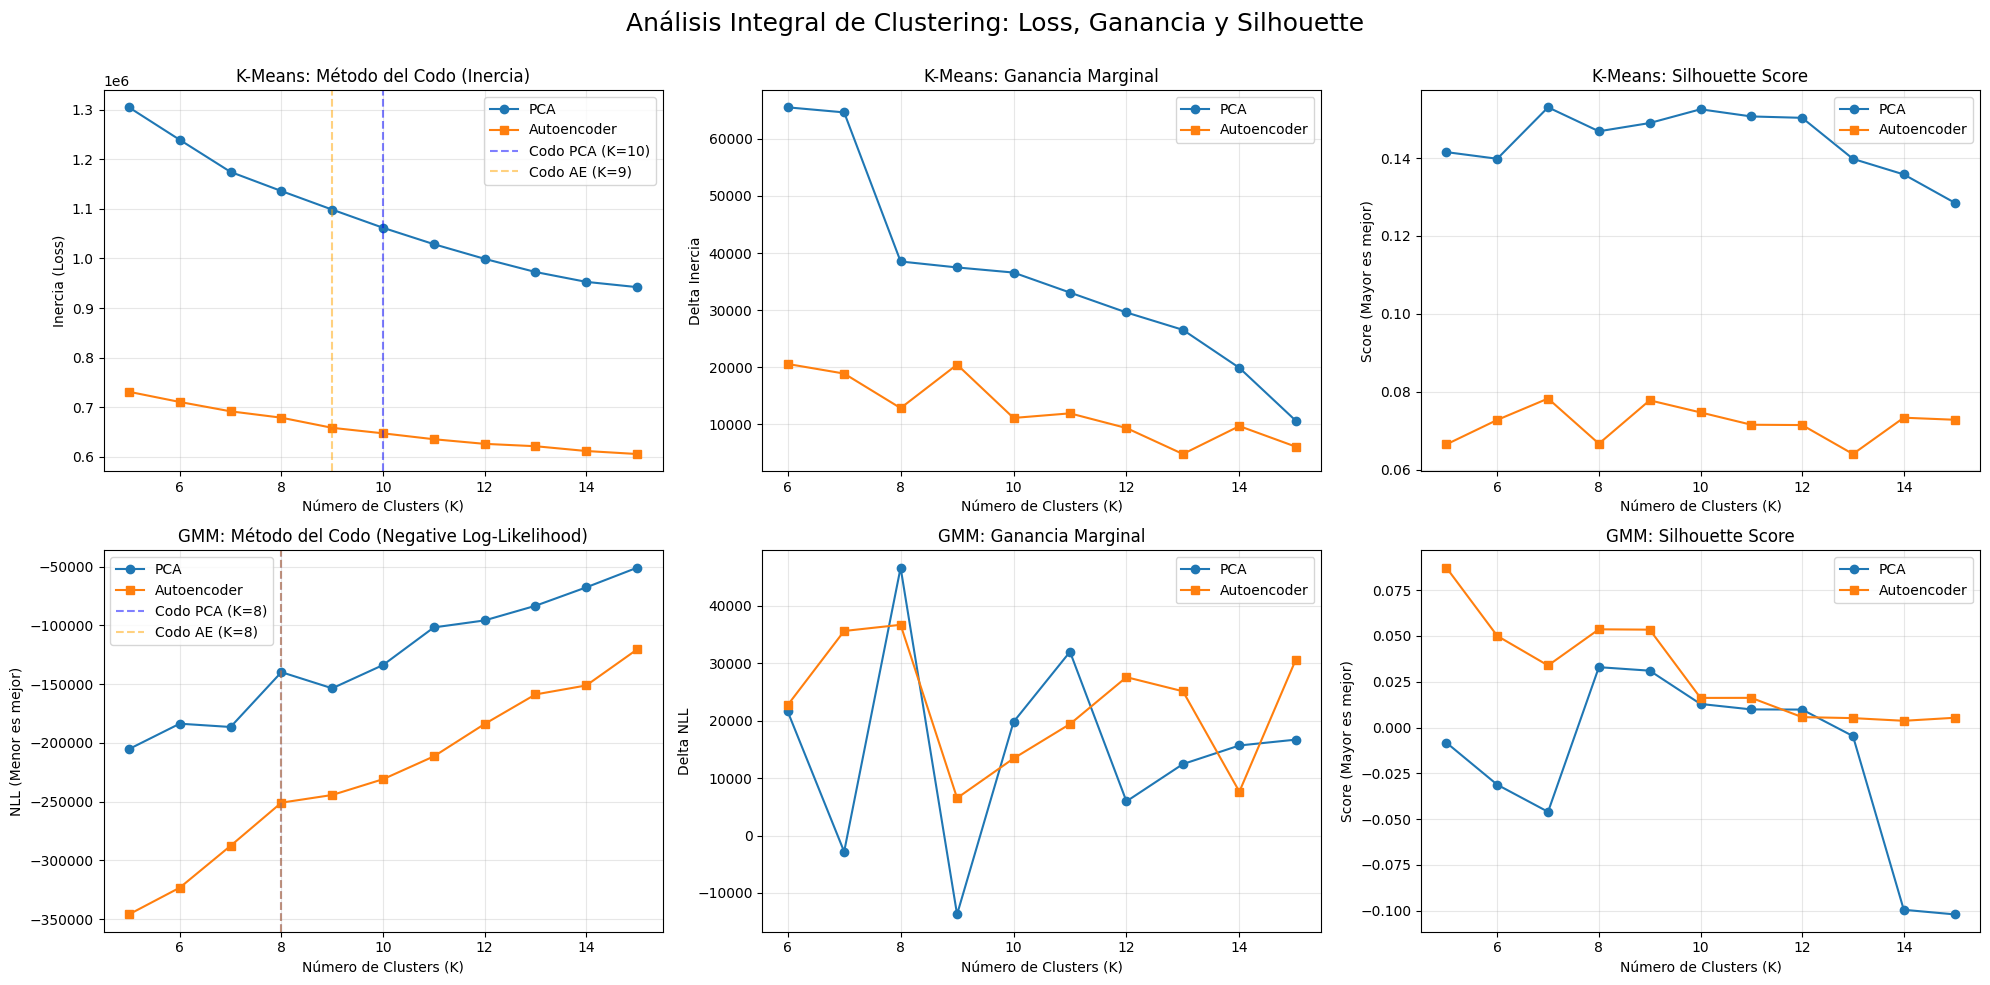

In [22]:
def find_elbow_point(x, y):
    """
    Encuentra el punto del codo matemáticamente calculando la máxima 
    distancia perpendicular desde cada punto a la línea que une los extremos.
    """
    x = np.array(x)
    y = np.array(y)
    
    # Coordenadas del primer y último punto
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    
    # Vector de la línea
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unitvec = line_vec / line_len
    
    distances = []
    for i in range(len(x)):
        p = np.array([x[i], y[i]])
        # Distancia del punto p1 al punto p
        p1_to_p = p - p1
        # Proyección sobre la línea
        proj = np.dot(p1_to_p, line_unitvec) * line_unitvec
        # El vector perpendicular es la diferencia
        perp_vec = p1_to_p - proj
        distances.append(np.linalg.norm(perp_vec))
        
    # El codo es el índice de la distancia máxima
    elbow_idx = np.argmax(distances)
    return x[elbow_idx], y[elbow_idx]

# --- 1. Calcular codos óptimos ---
# K-Means
k_opt_pca_kmeans, _ = find_elbow_point(list(k_values), losses_pca_kmeans)
k_opt_ae_kmeans, _ = find_elbow_point(list(k_values), losses_ae_kmeans)

# GMM
k_opt_pca_gmm, _ = find_elbow_point(list(k_values), log_likelihood_pca)
k_opt_ae_gmm, _ = find_elbow_point(list(k_values), log_likelihood_ae)

print(f"--- K Óptimo sugerido por el Codo Matemático ---")
print(f"K-Means -> PCA: {k_opt_pca_kmeans} | Autoencoder: {k_opt_ae_kmeans}")
print(f"GMM     -> PCA: {k_opt_pca_gmm} | Autoencoder: {k_opt_ae_gmm}")
print("-" * 50)

# --- 2. Graficación (Subplots de 2x3) ---
k_list = list(k_values)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Análisis Integral de Clustering: Loss, Ganancia y Silhouette', fontsize=18)

# ================= FILA 1: K-MEANS =================
# 1.1 Inercia (Elbow)
axes[0, 0].plot(k_list, losses_pca_kmeans, marker='o', label='PCA')
axes[0, 0].plot(k_list, losses_ae_kmeans, marker='s', label='Autoencoder')
axes[0, 0].axvline(x=k_opt_pca_kmeans, color='blue', linestyle='--', alpha=0.5, label=f'Codo PCA (K={k_opt_pca_kmeans})')
axes[0, 0].axvline(x=k_opt_ae_kmeans, color='orange', linestyle='--', alpha=0.5, label=f'Codo AE (K={k_opt_ae_kmeans})')
axes[0, 0].set_title('K-Means: Método del Codo (Inercia)')
axes[0, 0].set_xlabel('Número de Clusters (K)')
axes[0, 0].set_ylabel('Inercia (Loss)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1.2 Ganancia Marginal
axes[0, 1].plot(k_values_marginal, marginal_gain_pca_kmeans, marker='o', label='PCA')
axes[0, 1].plot(k_values_marginal, marginal_gain_ae_kmeans, marker='s', label='Autoencoder')
axes[0, 1].set_title('K-Means: Ganancia Marginal')
axes[0, 1].set_xlabel('Número de Clusters (K)')
axes[0, 1].set_ylabel('Delta Inercia')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 1.3 Silhouette
axes[0, 2].plot(k_list, silhouette_pca_kmeans, marker='o', label='PCA')
axes[0, 2].plot(k_list, silhouette_ae_kmeans, marker='s', label='Autoencoder')
axes[0, 2].set_title('K-Means: Silhouette Score')
axes[0, 2].set_xlabel('Número de Clusters (K)')
axes[0, 2].set_ylabel('Score (Mayor es mejor)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)


# ================= FILA 2: GMM =================
# 2.1 NLL (Elbow)
axes[1, 0].plot(k_list, log_likelihood_pca, marker='o', label='PCA')
axes[1, 0].plot(k_list, log_likelihood_ae, marker='s', label='Autoencoder')
axes[1, 0].axvline(x=k_opt_pca_gmm, color='blue', linestyle='--', alpha=0.5, label=f'Codo PCA (K={k_opt_pca_gmm})')
axes[1, 0].axvline(x=k_opt_ae_gmm, color='orange', linestyle='--', alpha=0.5, label=f'Codo AE (K={k_opt_ae_gmm})')
axes[1, 0].set_title('GMM: Método del Codo (Negative Log-Likelihood)')
axes[1, 0].set_xlabel('Número de Clusters (K)')
axes[1, 0].set_ylabel('NLL (Menor es mejor)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 2.2 Ganancia Marginal
axes[1, 1].plot(k_values_marginal, marginal_gain_pca_gmm, marker='o', label='PCA')
axes[1, 1].plot(k_values_marginal, marginal_gain_ae_gmm, marker='s', label='Autoencoder')
axes[1, 1].set_title('GMM: Ganancia Marginal')
axes[1, 1].set_xlabel('Número de Clusters (K)')
axes[1, 1].set_ylabel('Delta NLL')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 2.3 Silhouette
axes[1, 2].plot(k_list, silhouette_pca_gmm, marker='o', label='PCA')
axes[1, 2].plot(k_list, silhouette_ae_gmm, marker='s', label='Autoencoder')
axes[1, 2].set_title('GMM: Silhouette Score')
axes[1, 2].set_xlabel('Número de Clusters (K)')
axes[1, 2].set_ylabel('Score (Mayor es mejor)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [25]:
print("Iniciando transformación t-SNE sobre X_pca_3k...")
X_tsne_2d = tsne(X_pca_3k, max_iter=300)
print("¡t-SNE completado!")
# --- DEFINÍ TU K ÓPTIMO ACÁ ---
best_k = 8 # <-- CAMBIAR POR TU RESULTADO DEL INCISO ANTERIOR

# Extraemos las etiquetas que guardaste previamente para ese K
labels_opt_kmeans = labels_pca_dict_kmeans[best_k]
labels_opt_gmm = labels_pca_dict_gmm[best_k]
true_labels = y_pca_3k # Las clases reales de la muestra

# Nombres de las clases de Fashion MNIST para el gráfico
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Visualización t-SNE del Espacio Latente PCA (K={best_k})', fontsize=18)

# Gráfico 1: K-Means
scatter_k = axes[0].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_opt_kmeans, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('Asignaciones de K-Means')
axes[0].axis('off')

# Gráfico 2: GMM
scatter_g = axes[1].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=labels_opt_gmm, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('Asignaciones de GMM')
axes[1].axis('off')

plt.show()

# --- ANÁLISIS DE HOMOGENEIDAD Y CANTIDAD (Gráficos de Barras) ---
def plot_cluster_quality(labels_pred, true_labels, title):
    cluster_counts = np.bincount(labels_pred, minlength=best_k)
    
    # Matriz para guardar cuántos elementos de cada True Class hay en cada Cluster
    composition_matrix = np.zeros((best_k, 10))
    for c in range(best_k):
        true_in_c = true_labels[labels_pred == c]
        if len(true_in_c) > 0:
            counts = np.bincount(true_in_c, minlength=10)
            composition_matrix[c, :] = counts

    fig, ax = plt.subplots(figsize=(14, 6))
    
    bottom = np.zeros(best_k)
    x = np.arange(best_k)
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for i in range(10):
        bars = ax.bar(x, composition_matrix[:, i], bottom=bottom, label=class_names[i], color=colors[i])
        bottom += composition_matrix[:, i]
        
    ax.set_title(f'Homogeneidad y Tamaño de Clusters: {title}', fontsize=14)
    ax.set_xlabel('ID del Cluster (Algoritmo No Supervisado)')
    ax.set_ylabel('Cantidad de Muestras')
    ax.set_xticks(x)
    ax.set_xticklabels([f'C_{c}\n(N={int(cluster_counts[c])})' for c in x])
    ax.legend(title='Clase Real', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_cluster_quality(labels_opt_kmeans, true_labels, "K-Means sobre PCA")
plot_cluster_quality(labels_opt_gmm, true_labels, "GMM sobre PCA")

Iniciando transformación t-SNE sobre X_pca_3k...
t-SNE: Calculando afinidades P (esto puede tardar...)


NameError: name 'calculate_H_P' is not defined